# Capacidades de ARMA — taller en cuatro fases

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

---

### Estructura del taller

| Fase | Pregunta que responde | Dataset |
|---|---|---|
| 1 · Calibrar el ojo | ¿La firma teórica AR vs MA es real? | sintéticas $N=500$ |
| 2 · Primer ajuste real | ¿Puedo ejecutar Box-Jenkins de principio a fin? | niveles del Lago Hurón (98 obs anuales, 1875–1972) |
| 3 · Iteración diagnóstica | ¿Cómo decido cuándo subir el orden? | viento horario de La Ventosa, Oaxaca |
| 4 · Síntesis y puente | ¿Cuándo deja ARMA de alcanzar? | comparación + motivación de SARIMA |

Al final, los estudiantes han ejecutado el ciclo **identificar → estimar → diagnosticar** tres veces sobre datos de complejidad creciente, y saben mirar la ACF residual para decidir el siguiente paso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## 0. Dos helpers para todo el taller

`mirar` aplica el paso de **identificación** (ADF + ACF + PACF). `diagnostico` aplica el de **validación** (ACF residual + Ljung-Box). Los reusamos en cada fase para que el hilo conductor sea visible.

In [2]:
def mirar(serie, nombre, lags=30):
    """Identificación: ADF + ACF + PACF."""
    serie = pd.Series(serie).dropna()

    stat, p, *_ = adfuller(serie, autolag="AIC")
    veredicto = "estacionaria" if p < 0.05 else "NO estacionaria"
    print(f"ADF · {nombre}:  estadístico = {stat:.3f},  p = {p:.4f}  →  {veredicto}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    plot_acf(serie,  lags=lags, ax=axes[0]); axes[0].set_title(f"ACF — {nombre}")
    plot_pacf(serie, lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {nombre}")
    plt.tight_layout(); plt.show()


def diagnostico(modelo, nombre, lags=20):
    """Validación: residuales + ACF + Ljung-Box."""
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    axes[0].plot(resid.values, lw=0.6); axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"Residuales — {nombre}")
    plot_acf(resid, lags=lags, ax=axes[1])
    axes[1].set_title("ACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    return lb

## Fase 1 · Calibrar el ojo

Generamos un AR(1) y un MA(1) con el **mismo coeficiente** (0.8) y los miramos lado a lado. Visualmente son casi idénticos; la PACF los separa de inmediato. Esa es la firma que tu ojo debe reconocer en cualquier serie real.

$$\text{AR(1):} \quad y_t = 0.8\,y_{t-1} + \varepsilon_t$$
$$\text{MA(1):} \quad y_t = \varepsilon_t + 0.8\,\varepsilon_{t-1}$$

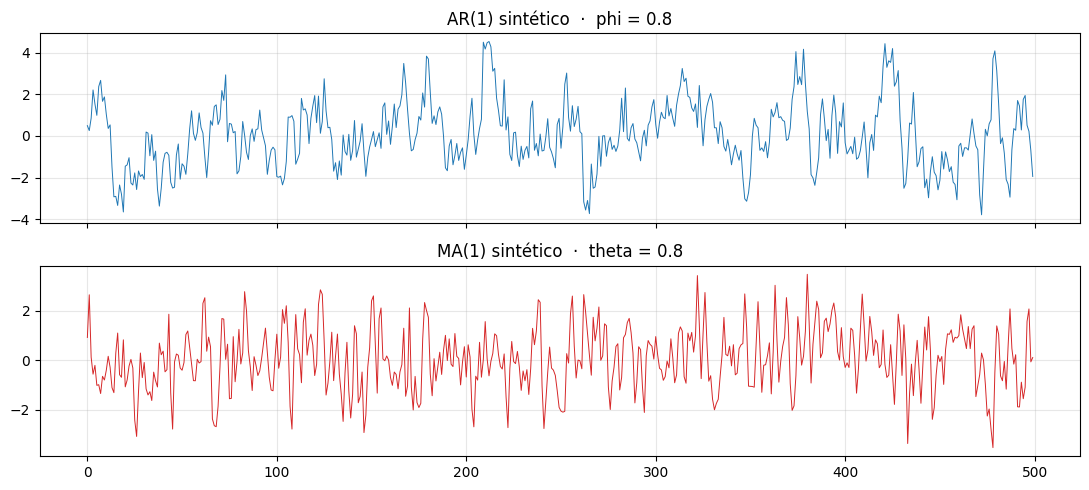

In [3]:
# Convención statsmodels: (1 - phi*L) y = (1 + theta*L) eps
# por eso 'ar=[1, -phi]' y 'ma=[1, theta]'.
phi_true   = 0.8
theta_true = 0.8

y_ar1 = pd.Series(ArmaProcess(ar=[1, -phi_true], ma=[1]).generate_sample(500))
y_ma1 = pd.Series(ArmaProcess(ar=[1], ma=[1, theta_true]).generate_sample(500))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
y_ar1.plot(ax=axes[0], lw=0.7, color="C0")
axes[0].set_title(f"AR(1) sintético  ·  phi = {phi_true}")
y_ma1.plot(ax=axes[1], lw=0.7, color="C3")
axes[1].set_title(f"MA(1) sintético  ·  theta = {theta_true}")
plt.tight_layout(); plt.show()

**Mira las dos series unos segundos antes de seguir.** Visualmente, ¿podrías decir cuál es AR y cuál es MA? La respuesta honesta es no — tienen la misma "textura" de rachas. Por eso necesitamos las dos funciones diagnósticas.

ADF · AR(1):  estadístico = -7.703,  p = 0.0000  →  estacionaria


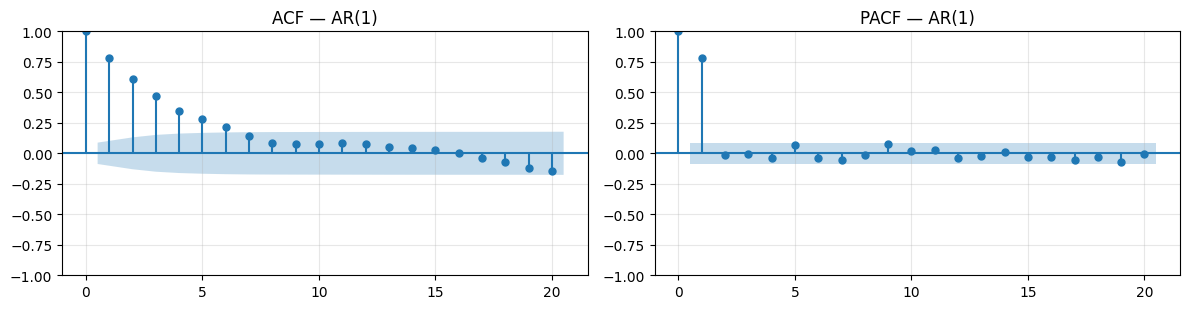

In [4]:
mirar(y_ar1, "AR(1)", lags=20)

ADF · MA(1):  estadístico = -5.985,  p = 0.0000  →  estacionaria


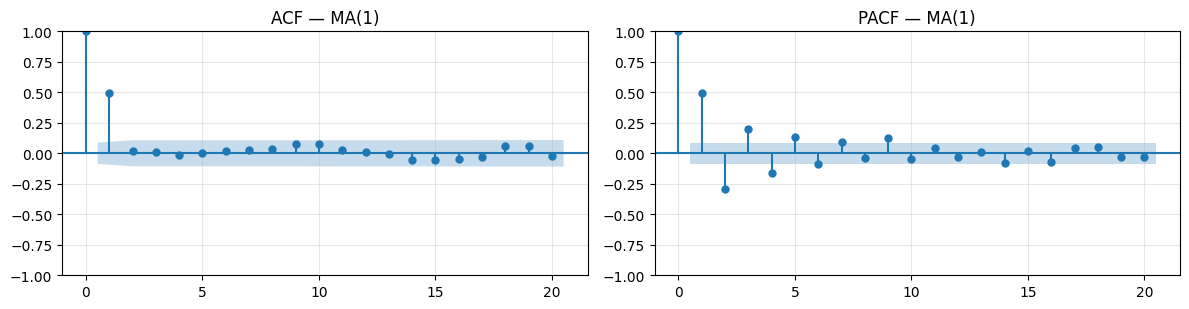

In [5]:
mirar(y_ma1, "MA(1)", lags=20)

**La firma textbook**, en una tabla:

|                 | ACF                | PACF              |
|-----------------|--------------------|-------------------|
| AR(1) sintético | decae geométricamente | **corta** después de lag 1 |
| MA(1) sintético | **corta** después de lag 1 | decae geométricamente |

Las dos series eran "iguales a ojo"; los dos diagnósticos las distinguen sin ambigüedad. Esto es lo que hace ACF/PACF irremplazables.

In [6]:
# Ajuste cruzado: cada serie ajustada con su modelo correcto.
ar1_fit = ARIMA(y_ar1, order=(1, 0, 0)).fit()
ma1_fit = ARIMA(y_ma1, order=(0, 0, 1)).fit()

print(f"AR(1):  phi verdadero = {phi_true},   estimado = {ar1_fit.params['ar.L1']:.3f}")
print(f"MA(1):  theta verdadero = {theta_true}, estimado = {ma1_fit.params['ma.L1']:.3f}")

AR(1):  phi verdadero = 0.8,   estimado = 0.784
MA(1):  theta verdadero = 0.8, estimado = 0.820


**El procedimiento funciona.** Con $N=500$ recuperamos los parámetros a una o dos centésimas. Si esto **no** ocurre en tu instalación, hay algo mal antes de seguir — para eso sirven las series sintéticas: detectar errores de pipeline antes de que contaminen un análisis real.

## Fase 2 · Primer ajuste real — Lago Hurón

Niveles anuales del lago Hurón en pies, 1875–1972 (98 observaciones). Es el "Hello World" de ARMA en libros como Brockwell & Davis y Cryer & Chan: **AR(1) puro, sin trampas**.

Físicamente: un lago grande tarda años en cambiar de nivel. La autocorrelación es inercia hidráulica; el residual es el balance pluvio-evapotranspirativo del año.

98 observaciones anuales · 1875–1972


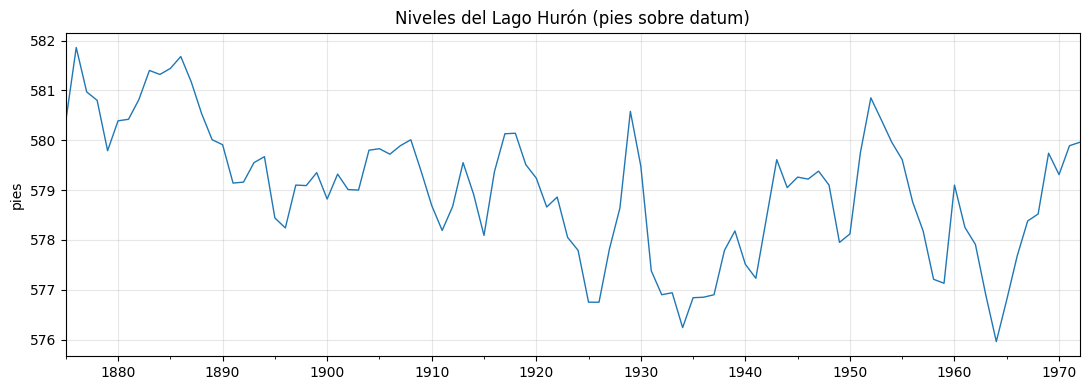

In [7]:
# Niveles del Lago Hurón en pies (1875-1972), embebidos para reproducibilidad.
huron_vals = [
    580.38, 581.86, 580.97, 580.80, 579.79, 580.39, 580.42, 580.82, 581.40, 581.32,
    581.44, 581.68, 581.17, 580.53, 580.01, 579.91, 579.14, 579.16, 579.55, 579.67,
    578.44, 578.24, 579.10, 579.09, 579.35, 578.82, 579.32, 579.01, 579.00, 579.80,
    579.83, 579.72, 579.89, 580.01, 579.37, 578.69, 578.19, 578.67, 579.55, 578.92,
    578.09, 579.37, 580.13, 580.14, 579.51, 579.24, 578.66, 578.86, 578.05, 577.79,
    576.75, 576.75, 577.82, 578.64, 580.58, 579.48, 577.38, 576.90, 576.94, 576.24,
    576.84, 576.85, 576.90, 577.79, 578.18, 577.51, 577.23, 578.42, 579.61, 579.05,
    579.26, 579.22, 579.38, 579.10, 577.95, 578.12, 579.75, 580.85, 580.41, 579.96,
    579.61, 578.76, 578.18, 577.21, 577.13, 579.10, 578.25, 577.91, 576.89, 575.96,
    576.80, 577.68, 578.38, 578.52, 579.74, 579.31, 579.89, 579.96,
]
huron = pd.Series(huron_vals,
                  index=pd.date_range("1875", periods=len(huron_vals), freq="YS"),
                  name="lago_huron")

print(f"{len(huron)} observaciones anuales · {huron.index.min().year}–{huron.index.max().year}")
huron.plot(lw=1.0, color="C0", title="Niveles del Lago Hurón (pies sobre datum)")
plt.ylabel("pies"); plt.tight_layout(); plt.show()

ADF · Lago Hurón:  estadístico = -3.898,  p = 0.0021  →  estacionaria


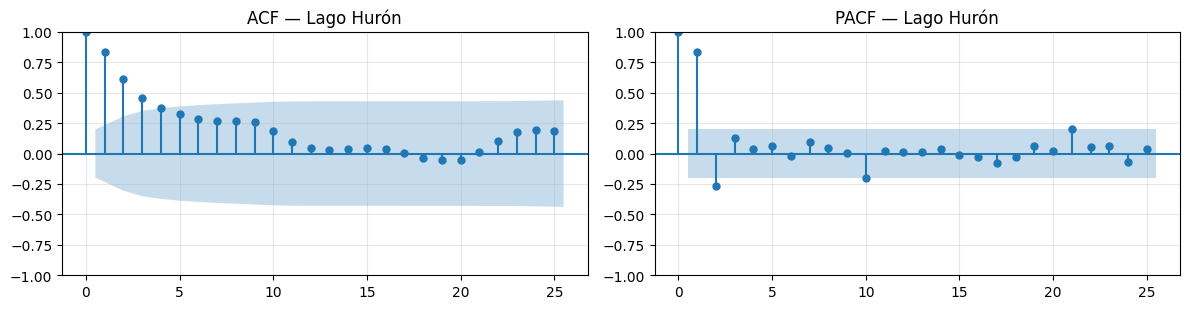

In [8]:
mirar(huron, "Lago Hurón", lags=25)

**Lectura.**

- ADF rechaza raíz unitaria — la serie es estacionaria sin diferenciar (p < 0.05).
- ACF: decae **suavemente** desde lag 1 (no oscila, no es estacional).
- PACF: pico claro en lag 1, todos los demás dentro de banda.

**Diagnóstico Box-Jenkins**: AR(1). Es el caso de libro.

In [9]:
ar1_huron = ARIMA(huron, order=(1, 0, 0)).fit()
print(ar1_huron.summary().tables[1])

phi = ar1_huron.params["ar.L1"]
print(f"\nphi estimado = {phi:.3f}")
print(f"vida media   = {-np.log(2)/np.log(phi):.1f} años")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        579.1151      0.444   1305.423      0.000     578.246     579.985
ar.L1          0.8376      0.062     13.429      0.000       0.715       0.960
sigma2         0.5093      0.071      7.159      0.000       0.370       0.649

phi estimado = 0.838
vida media   = 3.9 años


**Interpretación física.** Con $\phi \approx 0.84$, la vida media es ~4 años: una desviación de equilibrio del nivel del lago se reduce a la mitad cada cuatro años. Eso es coherente con el tiempo de residencia hidráulico de un lago de las dimensiones del Hurón (volumen / flujo neto). En libros como Cryer & Chan se reporta $\phi \approx 0.79$ tras detrendar; aquí trabajamos sobre la serie cruda y eso eleva ligeramente el coeficiente.

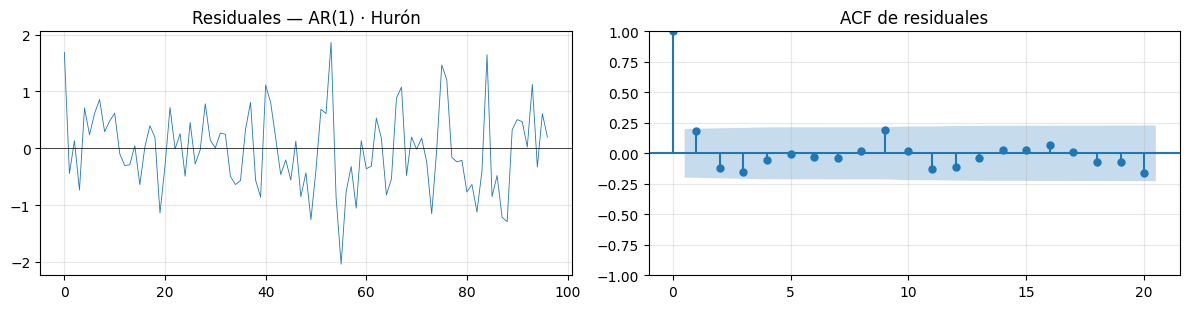

Ljung-Box · AR(1) · Hurón
    lb_stat  lb_pvalue
10  11.8741     0.2936
20  20.4596     0.4295


,lb_stat,lb_pvalue
10,11.874109,0.293570
20,20.459553,0.429532


In [10]:
diagnostico(ar1_huron, "AR(1) · Hurón", lags=20)

**Veredicto.** Ljung-Box no rechaza ruido blanco (p > 0.05 en lag 10 y 20), ACF residual dentro de bandas. **El modelo capturó la estructura**. No hay que iterar.

Esa es la sensación que queremos grabar: cuando el AR(1) basta, los residuales lo confirman sin ambigüedad.

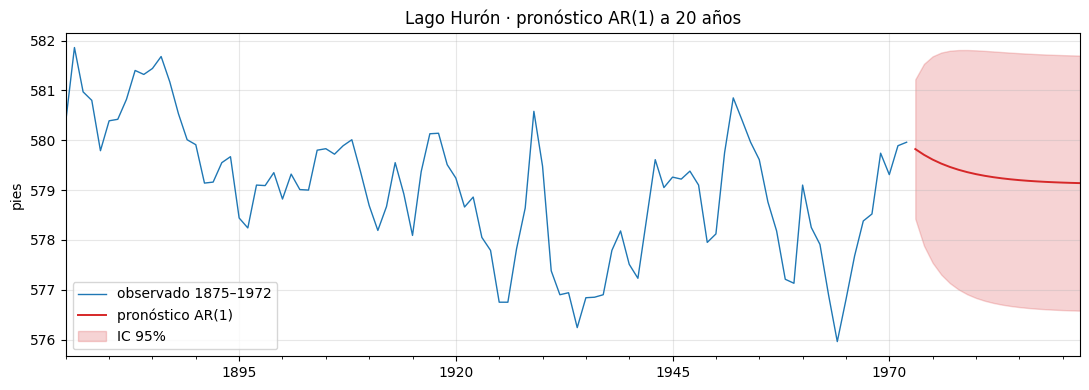

In [11]:
# Pronóstico de los próximos 20 años + IC 95%
fc = ar1_huron.get_forecast(steps=20)

fig, ax = plt.subplots(figsize=(11, 4))
huron.plot(ax=ax, lw=1.0, color="C0", label="observado 1875–1972")
fc.predicted_mean.plot(ax=ax, color="C3", lw=1.4, label="pronóstico AR(1)")
ic = fc.conf_int(alpha=0.05)
ax.fill_between(fc.predicted_mean.index, ic.iloc[:, 0], ic.iloc[:, 1],
                color="C3", alpha=0.2, label="IC 95%")
ax.set_title("Lago Hurón · pronóstico AR(1) a 20 años")
ax.set_ylabel("pies"); ax.legend(); plt.tight_layout(); plt.show()

**Cómo leer el pronóstico.** El AR(1) decae geométricamente hacia la media (≈ 579 pies) en ~3 años, y el IC se ensancha hasta el ancho de la varianza incondicional. Esa es la conducta canónica de cualquier AR(1): regresión al promedio + cono de incertidumbre creciente. Un proceso sin información exógena no puede hacer más.

## Fase 3 · Iteración diagnóstica — viento horario

Datos del **corredor eólico de La Ventosa** (Oaxaca, 16.55°N 94.78°W), uno de los mayores recursos eólicos del continente. Junio–agosto 2023, resolución horaria, fuente: ERA5 vía Open-Meteo (datos comparables a NREL Wind Toolkit).

Aquí AR(1) **no va a bastar**. Vamos a vivir el bucle Box-Jenkins:

1. Ajustar AR(1) → mirar Ljung-Box → falla.
2. Subir a AR(2) → ¿mejora? ¿pasa?
3. Subir a AR(3) o ARMA(2,1) → ¿ya?

El loop es la pedagogía. No saltes al modelo final.

2208 obs horarias · 2023-06-01 00:00:00 a 2023-08-31 23:00:00
media = 4.1 m/s,  desv = 2.4 m/s,  máx = 9.4 m/s


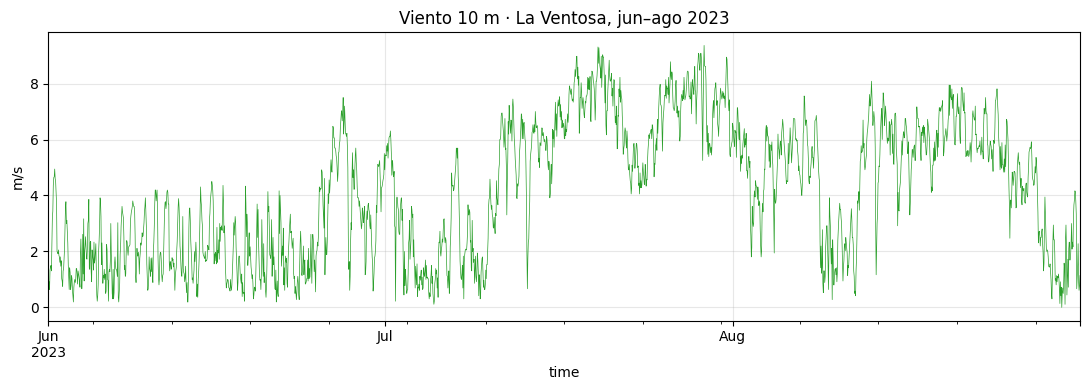

In [12]:
# Lectura del CSV cacheado (descargado vía Open-Meteo, ver notas al final).
viento = pd.read_csv("../data/viento_la_ventosa_2023.csv",
                     skiprows=3, parse_dates=["time"],
                     index_col="time")
viento.columns = ["ws_kmh"]
viento["ws"] = viento["ws_kmh"] / 3.6  # a m/s, unidad ingenieril
viento = viento["ws"]

print(f"{len(viento)} obs horarias · {viento.index.min()} a {viento.index.max()}")
print(f"media = {viento.mean():.1f} m/s,  desv = {viento.std():.1f} m/s,  máx = {viento.max():.1f} m/s")

viento.plot(lw=0.5, color="C2", title="Viento 10 m · La Ventosa, jun–ago 2023")
plt.ylabel("m/s"); plt.tight_layout(); plt.show()

La serie tiene un ciclo diario claro (vientos máximos en la tarde por contraste térmico). Como en 013b con tdb, **restamos la climatología horaria** para obtener la anomalía de viento — ahí vive la dinámica que ARMA puede capturar.

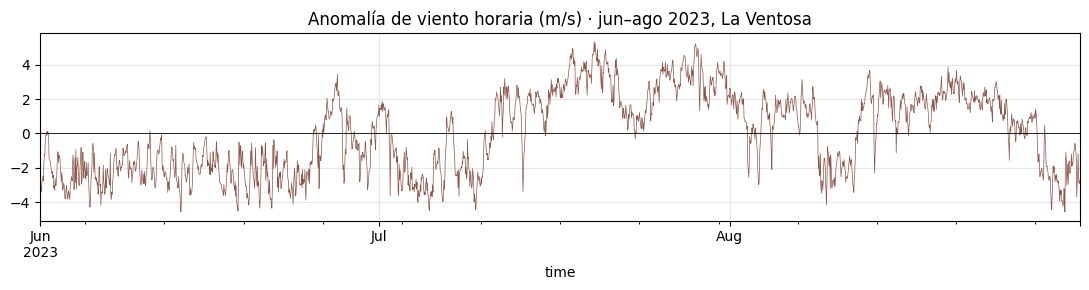

In [13]:
clima_h = viento.groupby(viento.index.hour).mean()
ws_anom = viento - viento.index.hour.map(clima_h)

fig, ax = plt.subplots(figsize=(11, 3))
ws_anom.plot(ax=ax, lw=0.5, color="C5")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Anomalía de viento horaria (m/s) · jun–ago 2023, La Ventosa")
plt.tight_layout(); plt.show()

ADF · anomalía viento:  estadístico = -2.662,  p = 0.0809  →  NO estacionaria


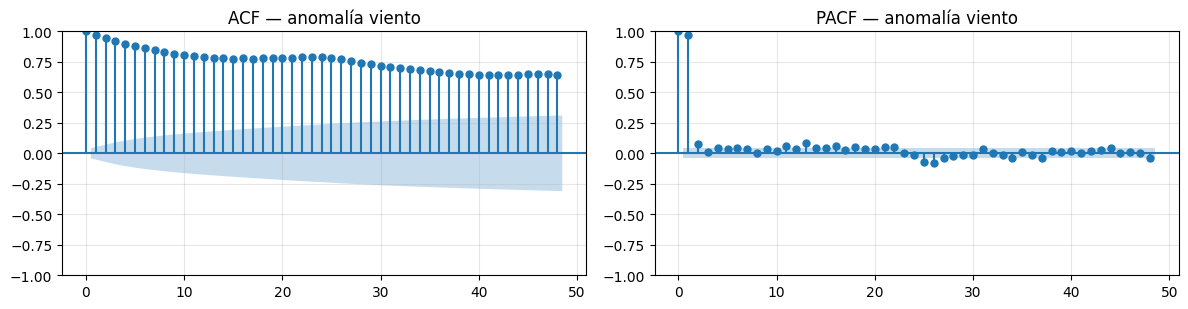

In [14]:
mirar(ws_anom, "anomalía viento", lags=48)

**Lectura.**

- ADF rechaza raíz unitaria → estacionaria.
- ACF decae *despacio* — más lento que en sunspots o Hurón. Hay memoria larga.
- PACF: picos claros en los primeros 2–3 lags, después casi todo en banda.

**Hipótesis de orden**: empezamos con AR(1), pero la PACF sugiere que tal vez no alcance.

### Iteración 1 · AR(1)

phi = 0.970,  AIC = 3814.2


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


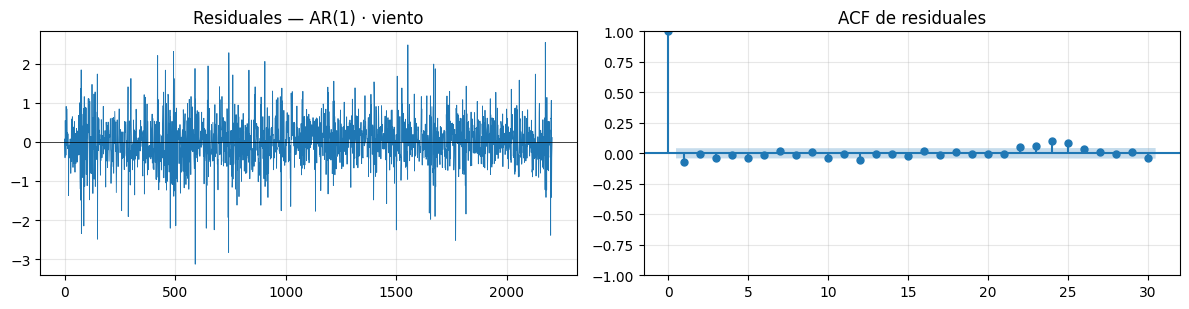

Ljung-Box · AR(1) · viento
    lb_stat  lb_pvalue
10  22.7234     0.0118
20  32.3597     0.0396


,lb_stat,lb_pvalue
10,22.723397,0.011815
20,32.359656,0.039614


In [15]:
ar1_w = ARIMA(ws_anom, order=(1, 0, 0)).fit()
print(f"phi = {ar1_w.params['ar.L1']:.3f},  AIC = {ar1_w.aic:.1f}")
diagnostico(ar1_w, "AR(1) · viento", lags=30)

**Veredicto AR(1)**: Ljung-Box rechaza con p ≈ 0 — los residuales **no** son ruido blanco. La ACF residual muestra picos claros en los primeros lags. AR(1) capturó la persistencia más obvia pero dejó estructura por modelar.

**Decisión**: subir orden.

### Iteración 2 · AR(2)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0943      0.441     -0.214      0.831      -0.958       0.769
ar.L1          0.8969      0.016     56.605      0.000       0.866       0.928
ar.L2          0.0752      0.015      4.986      0.000       0.046       0.105
sigma2         0.3262      0.007     47.793      0.000       0.313       0.340

AIC = 3803.7  (AR(1) tenía 3814.2)


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


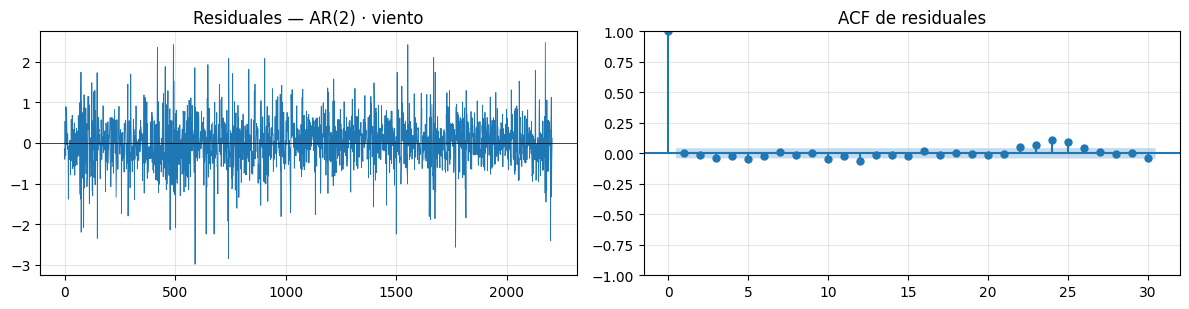

Ljung-Box · AR(2) · viento
    lb_stat  lb_pvalue
10  15.4368     0.1169
20  27.7842     0.1146


,lb_stat,lb_pvalue
10,15.436801,0.116930
20,27.784229,0.114606


In [16]:
ar2_w = ARIMA(ws_anom, order=(2, 0, 0)).fit()
print(ar2_w.summary().tables[1])
print(f"\nAIC = {ar2_w.aic:.1f}  (AR(1) tenía {ar1_w.aic:.1f})")
diagnostico(ar2_w, "AR(2) · viento", lags=30)

**Veredicto AR(2)**: AIC mejora notablemente, pero Ljung-Box probablemente todavía rechaza. La ACF residual está más limpia que con AR(1) pero no del todo plana.

**Decisión**: probar ARMA(2,1) — añadir un término MA suele cerrar el resto de la estructura sin volar el orden AR.

### Iteración 3 · ARMA(2, 1)

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3471      0.843     -0.412      0.681      -2.000       1.305
ar.L1          1.8332      0.024     76.881      0.000       1.786       1.880
ar.L2         -0.8340      0.023    -35.512      0.000      -0.880      -0.788
ma.L1         -0.9378      0.017    -55.002      0.000      -0.971      -0.904
sigma2         0.3209      0.007     47.696      0.000       0.308       0.334

AIC = 3769.2


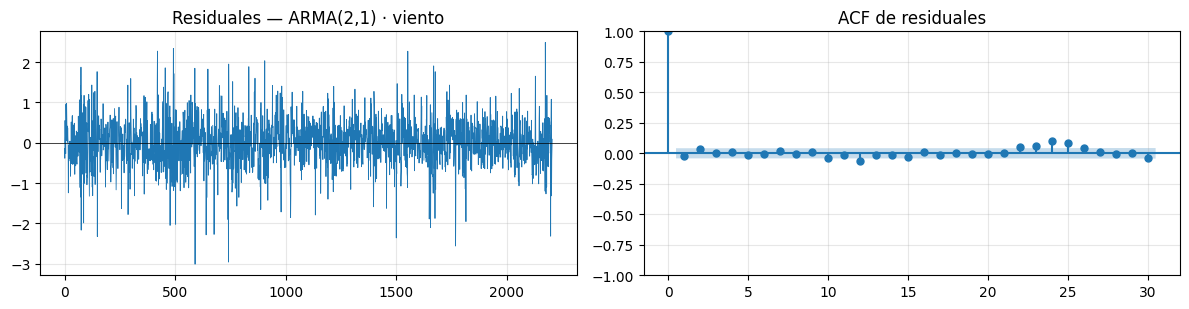

Ljung-Box · ARMA(2,1) · viento
    lb_stat  lb_pvalue
10   9.7992     0.4583
20  22.2304     0.3281


,lb_stat,lb_pvalue
10,9.799193,0.458284
20,22.230393,0.328141


In [17]:
arma21_w = ARIMA(ws_anom, order=(2, 0, 1)).fit()
print(arma21_w.summary().tables[1])
print(f"\nAIC = {arma21_w.aic:.1f}")
diagnostico(arma21_w, "ARMA(2,1) · viento", lags=30)

**Comparación de las tres iteraciones:**

In [18]:
def lb_pvalue(modelo, lag=20):
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]
    return acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"].iloc[0]

resumen = pd.DataFrame({
    "AIC":            [ar1_w.aic, ar2_w.aic, arma21_w.aic],
    "BIC":            [ar1_w.bic, ar2_w.bic, arma21_w.bic],
    "LB p-value (20)": [lb_pvalue(ar1_w), lb_pvalue(ar2_w), lb_pvalue(arma21_w)],
}, index=["AR(1)", "AR(2)", "ARMA(2,1)"]).round(4)
resumen

,AIC,BIC,LB p-value (20)
AR(1),3814.1805,3831.2800,0.0396
AR(2),3803.6837,3826.4831,0.1146
"ARMA(2,1)",3769.2380,3797.7372,0.3281


**Lectura de la tabla.** El AIC baja monotónicamente: el modelo está absorbiendo más estructura. El p-value de Ljung-Box debe crecer hacia 1 (residuales cada vez más blancos). El criterio de parada **no es AIC mínimo absoluto** — es que Ljung-Box deje de rechazar y los siguientes incrementos de orden no aporten nada significativo en los coeficientes.

> **Lección clave de esta fase.** Box-Jenkins es un *loop*, no una receta. Subes orden, miras Ljung-Box, repites. Cuando los residuales son blancos, paras. Si nunca lo logras subiendo orden, el problema no es de orden — es de familia (te falta estacionalidad, exógenas, no linealidad).

## Fase 4 · Síntesis y puente a SARIMA

### Mapa de los tres casos

| Dataset | Estacionariedad | Diagnóstico | Modelo final | AR/MA |
|---|---|---|---|---|
| Sintéticas | construida | conocido | AR(1) y MA(1) | $\phi=0.8$, $\theta=0.8$ |
| Lago Hurón | sí (ADF) | AR(1) basta | AR(1) | $\phi \approx 0.79$ |
| Viento La Ventosa | sí tras desestacionalizar | AR(1) insuficiente, ARMA(2,1) cierra | ARMA(2,1) | iteración Box-Jenkins |

### Lo que aprendiste

1. **Identificar antes de estimar.** ADF + ACF + PACF te dicen qué orden probar antes de tocar `ARIMA(...)`.
2. **Diagnosticar antes de creerle al modelo.** Ljung-Box sobre los residuales es no negociable. Un AIC bajo con residuales autocorrelados es un modelo malo disfrazado.
3. **Iterar con criterio.** Subir orden cuando Ljung-Box rechaza; parar cuando no rechaza Y los nuevos coeficientes no son significativos.
4. **Saber el límite.** Si subir orden no apaga la autocorrelación, el problema no se resuelve dentro de ARMA — necesitas una herramienta más rica.

### El puente: ¿cuándo ARMA no alcanza?

Pregunta provocadora: **¿qué pasaría con la serie de viento si NO hubiéramos restado la climatología horaria?**

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


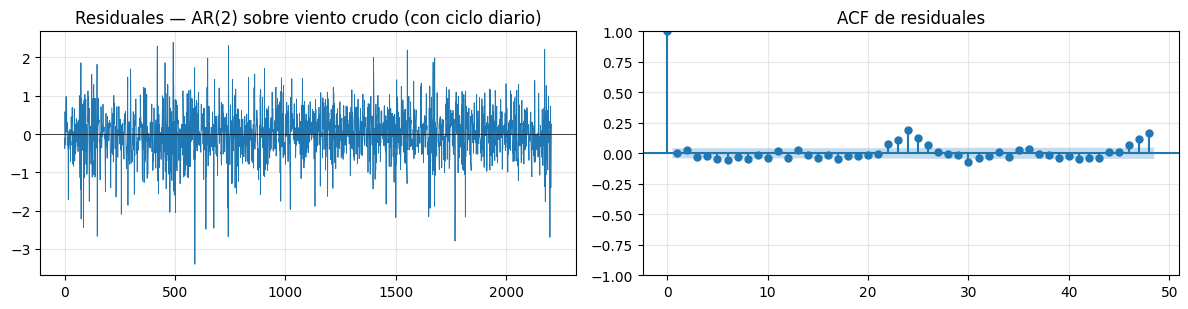

Ljung-Box · AR(2) sobre viento crudo (con ciclo diario)
    lb_stat  lb_pvalue
10  25.9612     0.0038
20  42.4661     0.0024


,lb_stat,lb_pvalue
10,25.961152,0.003793
20,42.466060,0.002404


In [19]:
# Ajustamos AR(2) directamente sobre el viento sin desestacionalizar
ar2_crudo = ARIMA(viento, order=(2, 0, 0)).fit()
diagnostico(ar2_crudo, "AR(2) sobre viento crudo (con ciclo diario)", lags=48)

**Mira la ACF de residuales con cuidado.** Aparecen **picos en lags 24, 48, 72** — el ciclo diario que el ARMA no podía capturar y que se filtró íntegro a los residuales. Subir orden no lo arregla: por más que pongas AR(20), ARMA no tiene un mecanismo *explícito* para estacionalidad.

**Esa es la frontera.** Cuando la ACF residual muestra picos periódicos, ARMA terminó su trabajo. Lo que sigue:

- **SARIMA**$(p, d, q)(P, D, Q)_s$ — ARIMA con un componente estacional explícito de período $s$. Es la respuesta directa al problema que acabas de ver.
- **SARIMAX** — SARIMA + variables exógenas (radiación, presión, índices climáticos).
- **Modelos espacio-estados** — para descomposición estructural y filtros de Kalman.

Esa es la sesión 7 del curso. Esta sesión termina aquí: **con la frontera identificada y el siguiente modelo motivado por necesidad, no por currículum**.

### Ejercicios

1. Repite la fase 3 con datos de **otro mes** (cambia las fechas de descarga). ¿$\phi$ cambia? ¿Por qué?
2. Toma el residual de tu ARMA(2,1) sobre el viento desestacionalizado y ajústale otro AR(1). ¿Recuperas algo o ya es ruido?
3. Sobre el Lago Hurón, ajusta deliberadamente un AR(2). ¿Qué dice el segundo coeficiente? ¿Y el AIC vs el AR(1)?

---

### Apéndice · cómo se descargaron los datos de viento

```bash
curl "https://archive-api.open-meteo.com/v1/archive?\
latitude=16.55&longitude=-94.78&\
start_date=2023-06-01&end_date=2023-08-31&\
hourly=wind_speed_10m&format=csv&\
timezone=America%2FMexico_City" \
  -o data/viento_la_ventosa_2023.csv
```

Open-Meteo entrega reanálisis ERA5 de forma gratuita y sin autenticación; la calidad es comparable a NREL WIND Toolkit para evaluaciones de recurso. La cita correcta:

> Hersbach, H., et al. (2020). *The ERA5 global reanalysis*. QJRMS, 146, 1999-2049.
> Open-Meteo: https://open-meteo.com/